# Data Exploration
Explore MS MARCO training pairs and the book corpus used for demo search.

In [1]:
import json
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re

sys.path.insert(0, str(Path("src").resolve()))

PROJECT_ROOT = Path("..").resolve()
TRAIN_PATH = PROJECT_ROOT / "data/pairs/train.json"
VAL_PATH   = PROJECT_ROOT / "data/pairs/val.json"
TEST_PATH  = PROJECT_ROOT / "data/pairs/test.json"

## 1. Load splits

In [2]:
def load_json(path):
    with open(path, encoding="utf-8") as f:
        return json.load(f)

train = load_json(TRAIN_PATH)
val   = load_json(VAL_PATH)
test  = load_json(TEST_PATH)

print(f"Train : {len(train):,}")
print(f"Val   : {len(val):,}")
print(f"Test  : {len(test):,}")
print(f"Total : {len(train)+len(val)+len(test):,}")

Train : 45,000
Val   : 2,500
Test  : 2,500
Total : 50,000


## 2. Schema inspection

In [3]:
sample = train[0]
print("Keys:", list(sample.keys()))
print("\nquery")
print(sample["query"])
print("\npositive")
print(sample["positive"][:300])
print("\nnegative")
print(sample["negative"][:300])

Keys: ['query', 'positive', 'negative']

--- query ---
moonrunes definition

--- positive ---
moonrunes definition: Noun (uncountable) 1. (slang, derogatory) An incomprehensible writing script. Usually used to refer to Chinese characters, Hiragana, Katakana or any other East Asian writing script.Origin moon +‎ runes...

--- negative ---
Moonspeak. Moonspeak is a somewhat derogatory internet slang term for any non-English language text. Though the term can be used with any language other than English it is typically only used with languages using a non-Latin alphabet, particularly Japanese.


## 3. Text length distributions (words)

In [4]:
def word_counts(data, field):
    return [len(item[field].split()) for item in data]

q_lens  = word_counts(train, "query")
pos_lens = word_counts(train, "positive")
neg_lens = word_counts(train, "negative")

for name, arr in [("query", q_lens), ("positive", pos_lens), ("negative", neg_lens)]:
    print(f"{name:>10}  mean={np.mean(arr):.1f}  median={np.median(arr):.1f}  "
          f"min={min(arr)}  max={max(arr)}  p95={np.percentile(arr,95):.0f}")

     query  mean=5.5  median=5.0  min=1  max=34  p95=10


  positive  mean=57.5  median=51.0  min=6  max=221  p95=103
  negative  mean=55.0  median=50.0  min=1  max=191  p95=100


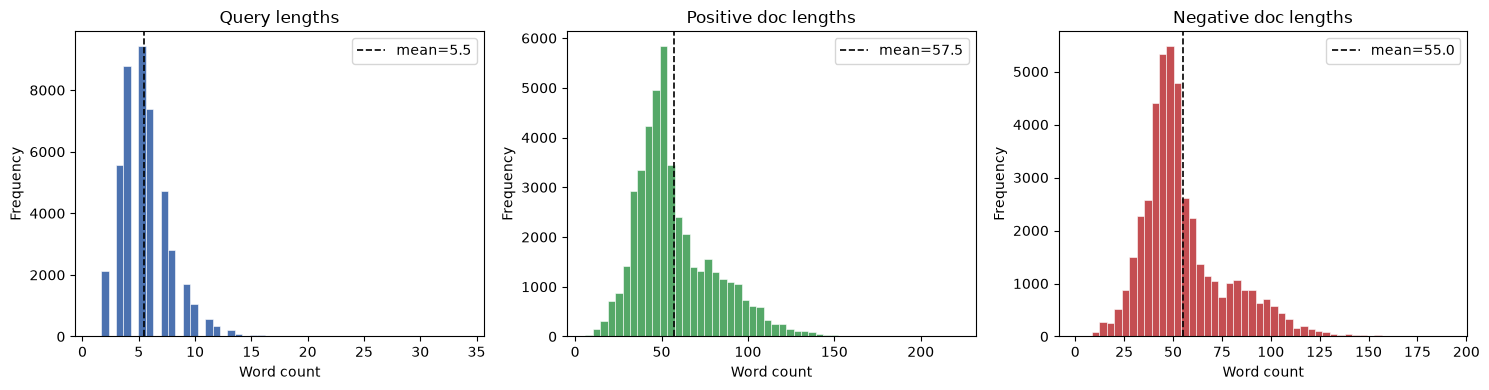

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [("Query lengths", q_lens, "#4C72B0"),
         ("Positive doc lengths", pos_lens, "#55A868"),
         ("Negative doc lengths", neg_lens, "#C44E52")]

for ax, (title, data, color) in zip(axes, pairs):
    ax.hist(data, bins=50, color=color, edgecolor="white", linewidth=0.4)
    ax.axvline(np.mean(data), color="black", linestyle="--", linewidth=1.2, label=f"mean={np.mean(data):.1f}")
    ax.set_title(title)
    ax.set_xlabel("Word count")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.savefig("length_distributions.png", dpi=120)
plt.show()

## 4. Query type analysis

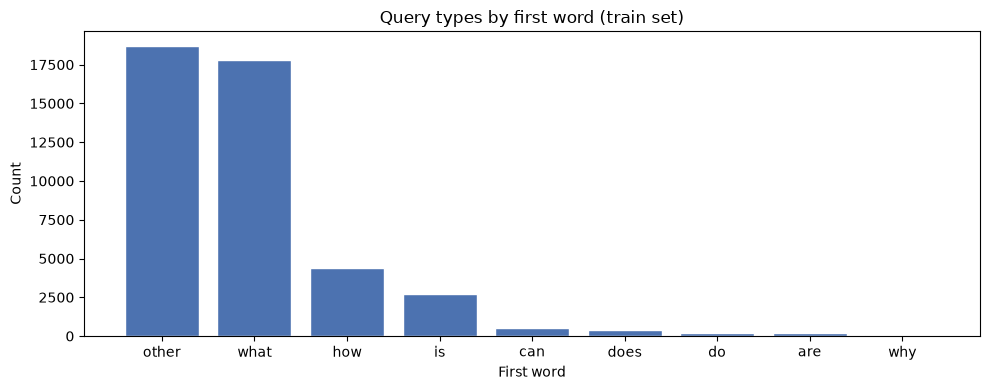

In [6]:
question_words = ["what", "who", "when", "where", "why", "how", "which", "is", "are", "can", "does", "do"]

def query_type(q):
    first = q.strip().lower().split()[0] if q.strip() else ""
    return first if first in question_words else "other"

type_counts = Counter(query_type(item["query"]) for item in train)

labels, values = zip(*type_counts.most_common(10))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(labels, values, color="#4C72B0", edgecolor="white")
ax.set_title("Query types by first word (train set)")
ax.set_xlabel("First word")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("query_types.png", dpi=120)
plt.show()

## 5. Vocabulary overlap between query and positive doc

Mean overlap (query ∩ positive / query): 0.645
Median: 0.667


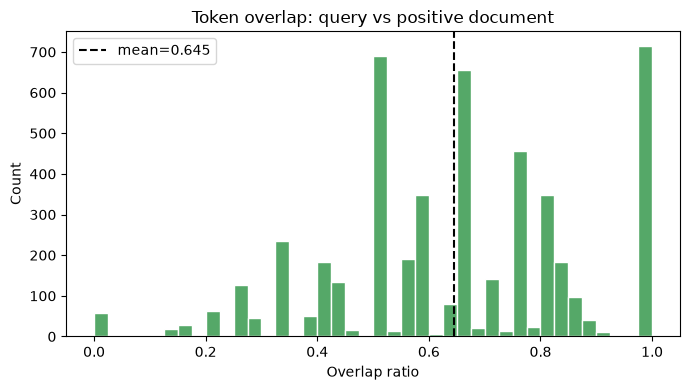

In [7]:
def token_overlap(a, b):
    ta = set(re.findall(r"\w+", a.lower()))
    tb = set(re.findall(r"\w+", b.lower()))
    if not ta:
        return 0.0
    return len(ta & tb) / len(ta)

overlaps = [token_overlap(item["query"], item["positive"]) for item in train[:5000]]

print(f"Mean overlap (query ∩ positive / query): {np.mean(overlaps):.3f}")
print(f"Median: {np.median(overlaps):.3f}")

plt.figure(figsize=(7, 4))
plt.hist(overlaps, bins=40, color="#55A868", edgecolor="white")
plt.axvline(np.mean(overlaps), color="black", linestyle="--", label=f"mean={np.mean(overlaps):.3f}")
plt.title("Token overlap: query vs positive document")
plt.xlabel("Overlap ratio")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("token_overlap.png", dpi=120)
plt.show()

## 6. Positive vs Negative similarity (lexical)

In [8]:
pos_neg_overlap = [token_overlap(item["positive"], item["negative"]) for item in train[:5000]]
query_pos_overlap = [token_overlap(item["query"], item["positive"]) for item in train[:5000]]
query_neg_overlap = [token_overlap(item["query"], item["negative"]) for item in train[:5000]]

print(f"query - positive overlap : {np.mean(query_pos_overlap):.3f}")
print(f"query - negative overlap : {np.mean(query_neg_overlap):.3f}")
print(f"positive - negative overlap: {np.mean(pos_neg_overlap):.3f}")

query↔positive overlap : 0.645
query↔negative overlap : 0.513
positive↔negative overlap: 0.266


## 7. Book corpus stats

In [9]:
sys.path.insert(0, str((PROJECT_ROOT / "src").resolve()))
from corpus import build_book_corpus, corpus_stats

documents, metadata = build_book_corpus()
stats = corpus_stats(metadata)

print("Book corpus statistics")
for k, v in stats.items():
    print(f"  {k:<16} {v:.3f}" if isinstance(v, float) else f"  {k:<16} {v}")

Book corpus statistics
----------------------
  n_chunks         1119
  n_sources        23
  min_words        200
  max_words        725
  mean_words       264.890
  within_target    0.960


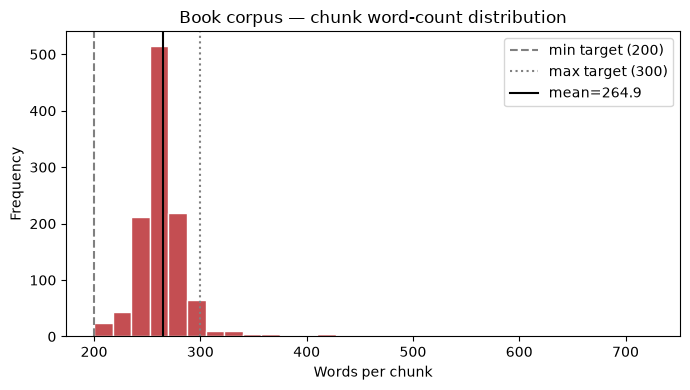

In [10]:
chunk_lengths = [m["n_words"] for m in metadata]

plt.figure(figsize=(7, 4))
plt.hist(chunk_lengths, bins=30, color="#C44E52", edgecolor="white")
plt.axvline(200, color="gray", linestyle="--", label="min target (200)")
plt.axvline(300, color="gray", linestyle=":",  label="max target (300)")
plt.axvline(np.mean(chunk_lengths), color="black", linestyle="-", linewidth=1.5,
            label=f"mean={np.mean(chunk_lengths):.1f}")
plt.title("Book corpus — chunk word-count distribution")
plt.xlabel("Words per chunk")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("chunk_lengths.png", dpi=120)
plt.show()

## 8. Sample pairs

In [11]:
import random
random.seed(0)
samples = random.sample(train, 3)
for i, s in enumerate(samples, 1):
    print(f"Example {i}")
    print(f"Query   : {s['query']}")
    print(f"Positive: {s['positive'][:200]}...")
    print(f"Negative: {s['negative'][:200]}...")
    print()

=== Example 1 ===
Query   : is tomato sauce a liquid
Positive: For the table sauce referred to in some countries as tomato sauce, see Ketchup. Tomato sauce refers to any of a very large number of sauces made primarily from tomatoes, usually to be served as part o...
Negative: Home-canned tomato sauce have been a tradition for many generations. In the middle of the winter, you can use the tomato sauce to make a fresh spaghetti sauce, lasagna, chili, or other tomato-based me...

=== Example 2 ===
Query   : what is a critical path in project management
Positive: If there is a delay in any task on the critical path, then your whole project will be delayed. Although many projects have only one critical path, some projects may have multiple critical paths. The c...
Negative: Let us assume that a project can be broken down into activities A, B, C and D. The Critical Path runs along A, B and D and task C is parallel to sub-activity D. In this scenario if task B stretches be...

=== Example 3 =